<a href="https://colab.research.google.com/github/Suthirtha2004/ml-from-scratch/blob/main/Implementing_Gradient_Descent_And_Cost_Function_Single_Feature_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Lets start with Numpy Basics Gradually Implementing Gradient Descent and Cost Function from Scratch





In [ ]:
import numpy as np
import time


In [ ]:
#Creating vectors with Numpy - Usually the first parameter in numpy is the size of the vector

x = np.zeros((4))
print(f"{x} , shape = {x.shape} , datatype = {x.dtype}")

x= np.zeros((4,))
print(f"{x} , shape = {x.shape} , datatype = {x.dtype}")

x = np.random.random_sample((4))
print(f"{x} , shape = {x.shape} , datatype = {x.dtype}")


[0. 0. 0. 0.] , shape = (4,) , datatype = float64
[0. 0. 0. 0.] , shape = (4,) , datatype = float64
[0.51991639 0.09279934 0.97947407 0.03322439] , shape = (4,) , datatype = float64


In [ ]:
# Few Numpy routines dont take a size
x = np.arange(4)
print(f"{x} , shape = {x.shape} , datatype = {x.dtype}")
x = np.random.rand(4)
print(f"{x} , shape = {x.shape} , datatype = {x.dtype}")

[0 1 2 3] , shape = (4,) , datatype = int64
[0.246926   0.98637822 0.85766404 0.73421996] , shape = (4,) , datatype = float64


In [ ]:
# Using numpy array to manually enter values

x = np.array([4,5,6,7])
print(f"{x} , shape = {x.shape} , datatype = {x.dtype}")

x = np.array([5.,6,7,8,9])
print(f"{x} , shape = {x.shape} , datatype = {x.dtype}")


[4 5 6 7] , shape = (4,) , datatype = int64
[5. 6. 7. 8. 9.] , shape = (5,) , datatype = float64


In [ ]:
# Indexing and Slicing - Numpy arrays starts indexing from 0

x = np.arange((10))
print(f"x[2] : {x[2]}")

#Accessing negative elements generally starts from last index
print(f"x[-2] : {x[-2]}")

#Slicing parameters - (start:stop:steps)

a = np.arange((15))
print(f"a  : {a}")

ans1 = a[2:9:1]
print(f"a[2:9:1] : {ans1}")

ans2 = a[:7]
print(f"a[:7] : {ans2}")

ans3 = a[:]
print(f"a[:] : {ans3}")

ans4 = a[6:]
print(f"a[6:] : {ans4}")


x[2] : 2
x[-2] : 8
a  : [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
a[2:9:1] : [2 3 4 5 6 7 8]
a[:7] : [0 1 2 3 4 5 6]
a[:] : [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
a[6:] : [ 6  7  8  9 10 11 12 13 14]


In [ ]:
# Single Vector Operations using numpy

a = np.array([9,10,11,12,16])
b = -a
print(f"b : {b}")

c = np.sum(a)
print(f"Sum of all elements : {c}")

d = np.mean(a)
print(f"Mean of all elements : {d}")

b : [ -9 -10 -11 -12 -16]
Sum of all elements : 58
Mean of all elements : 11.6


In [ ]:
# Vector - Vector Element Wise Operations

a = np.array([1,2,3,4,6])
b = np.array([10,11,12,13,14])
print(f"Element wise element sum : {a+b}")


Element wise element sum : [11 13 15 17 20]


In [ ]:
# Vectors can be scaled by multiplying with a scalar value

x = np.array([78,12,23,45])
ans = 5*x;
print(f"Scaled values : {ans}")

Scaled values : [390  60 115 225]


In [ ]:
#Implementing Dot Product between Vectors

def my_dot_pro(x,y):
  """
    Args : x(ndarray,)
           y(ndarray)

    Output : gives the dot product of x and y
  """
  dot_pro = 0;
  for i in range(x.shape[0]):
    dot_pro = dot_pro + x[i] * y[i];

  return dot_pro

In [ ]:
x = np.array([10,12,15,17])
y = np.array([20,21,22,23])

print(f"My dot product : {my_dot_pro(x,y)}")

My dot product : 1173


In [ ]:
#Now using the np.dot func -because NumPy makes better use of available data parallelism in the underlying hardware. GPU's and modern CPU's implement Single Instruction, Multiple Data (SIMD) pipelines allowing multiple operations to be issued in parallel. This is critical in Machine Learning where the data sets are often very large.

x = x = np.array([10,12,15,17])
y = np.array([20,21,22,23])

result = np.dot(x,y)
print(f"The result : {result} and shape : {result.shape}")

The result : 1173 and shape : ()


In [ ]:
# Matrices - 2D arrays vectors containing vectors within themselves

a = np.zeros((1,5))
print(f"a : {a} a.shape : {a.shape}")

a = np.zeros((3,4))
print(f"a : {a} a.shape : {a.shape}")

a = np.zeros((1,1))
print(f"a : {a} a.shape : {a.shape}")

a : [[0. 0. 0. 0. 0.]] a.shape : (1, 5)
a : [[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]] a.shape : (3, 4)
a : [[0.]] a.shape : (1, 1)


In [ ]:
# Creating matrices using np array

x = np.array([[3],[4],[8]])
print(f"x : {x} and x.shape : {x.shape}")

y = np.array([[1],
              [3],
              [4]
])
print(f"y : {y} y.shape : {y.shape}")

x : [[3]
 [4]
 [8]] and x.shape : (3, 1)
y : [[1]
 [3]
 [4]] y.shape : (3, 1)


In [ ]:
# Indexing in matrices - might return a value or a row/column

x = np.arange(6).reshape(-1,2)
print(f"x : {x} and, \nshape : {x.shape}")

a = x[2][1]
print(f"x[2][1] : {a} , shape : {a.shape} , type : {type(a)}")

b = x[1]
print(f"x[1] : {b} , shape : {b.shape} , type : {type(b)}")

x : [[0 1]
 [2 3]
 [4 5]] and, 
shape : (3, 2)
x[2][1] : 5 , shape : () , type : <class 'numpy.int64'>
x[1] : [2 3] , shape : (2,) , type : <class 'numpy.ndarray'>


In [ ]:
# Slicing in Matrices

a = np.arange(20).reshape(-1,10)

ans1 = a[:,:]
print(f"ans : {ans1} and shape : {ans1.shape}")

ans2 = a[1,3:9:1]
print(f"ans : {ans2} and shape : {ans2.shape}")

ans3 = a[:,2:7:2] #This print the elements of both rows
print(f"ans : {ans2} and shape : {ans3.shape}")

ans4 =  a[1:]
print(f"same as a[1] : {ans4} shape : {ans4.shape}")


ans : [[ 0  1  2  3  4  5  6  7  8  9]
 [10 11 12 13 14 15 16 17 18 19]] and shape : (2, 10)
ans : [13 14 15 16 17 18] and shape : (6,)
ans : [13 14 15 16 17 18] and shape : (2, 3)
same as a[1] : [[10 11 12 13 14 15 16 17 18 19]] shape : (1, 10)


**Basic Linear Regression Model with weight and Bias**


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
# Taking input and target variables as x_train and y_train

x_train = np.array([1.0,2.0])
y_train = np.array([300,500])

m = x_train.shape[0] # len(x_train)
print(f"No of training examples : {m}")

# Access x^i and y^i
i = 0
print(f"x^i and y^i : {x_train[i]} and {y_train[i]}")

No of training examples : 2
x^i and y^i : 1.0 and 300


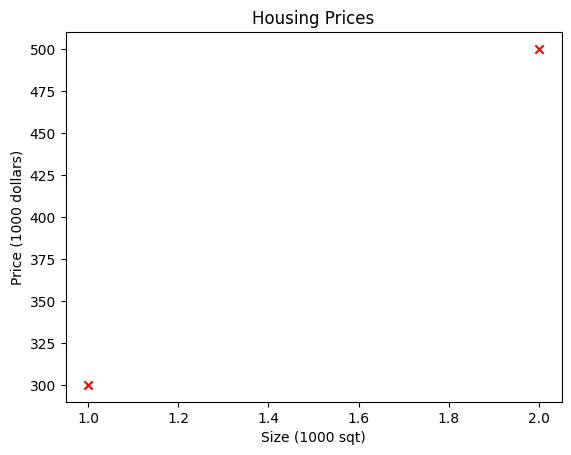

In [ ]:
# Basic plotting of Points - Scatter Plot

plt.scatter(x_train,y_train,marker='x',c='r')
plt.title("Housing Prices")
plt.xlabel("Size (1000 sqt)")
plt.ylabel("Price (1000 dollars)")

plt.show()

the model function for linear regression (which is a function that maps from

`x` to `y`) is represented as $$ f_{w,b}(x^{(i)}) = wx^{(i)} + b $$

In [ ]:
#Set weight and bias
w1 = 200
b1 = 100

print(f"w : {w1}")
print(f"b :{b1}")

# Prepare the Model

def linear_model(x,w,b):
  """
    Arguments :  x = array (data,examples)
                 model parameters
                 w = weight
                 b = bias
    Output : f_xb(x) : Value predicted (Array)

  """

  m = x.shape[0];
  f_wb = np.zeros(m)
  for i in range(m):
    f_wb[i] = x[i]*w + b

  return f_wb


w : 200
b :100


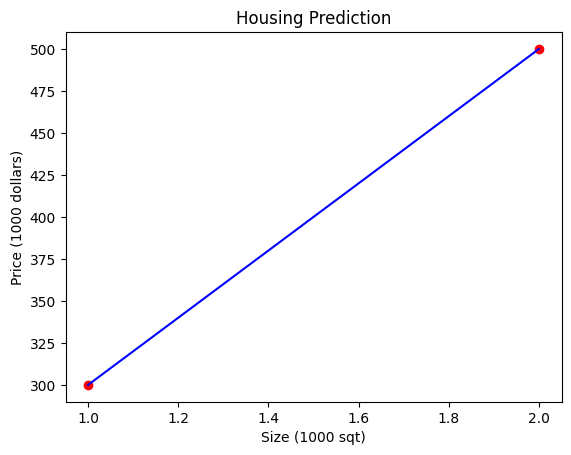

In [ ]:
value_predicted = linear_model(x_train,w1,b1)

plt.plot(x_train,value_predicted,label="Predicted values",c= 'b')

plt.scatter(x_train,y_train,label="Data points",c='r')

plt.title("Housing Prediction")

plt.xlabel("Size (1000 sqt)")
plt.ylabel("Price (1000 dollars)")

plt.show()

In [ ]:
# Predict Cost for Unknown House Size

w = 200
b = 100
x_i = 1.5
cost_price = x_i * w + b;
print(f"Cost price : {cost_price}")

Cost price : 400.0


In [ ]:
# Implementing Cost Function for Single Parameter Dataset - House Prediction Set

x_train= np.array([1.0,2.0])
y_train = np.array([300.0,500.0])

def compute_cost(x,y,w,b):
  """
    Arguments :
                x : Data parameters(ndarray),
                y : Output data(ndarray)
                w , b : Model parameters
    Output :
            total_cost : Measure to indicate how well the w and b parameters are used to
            fit the x values and give results
  """

  m = x.shape[0]
  total_cost = 0
  cost_sum = 0
  for i in range(m):
    f_wb = w*x[i] + b
    cost = (f_wb - y[i])**2
    cost_sum += cost

  total_cost = (1/(2*m))*cost_sum

  return total_cost


In [ ]:
w = np.array([100,200,300,400])
b = np.array([50,100,60,30])

n = w.shape[0]
cost = np.zeros((n))
for i in range(n):
  cost[i] = compute_cost(x_train,y_train,w[i],b[i])


print(f"The cost function yeilds : {cost}")

The cost function yeilds : [21250.     0.  7300. 31450.]


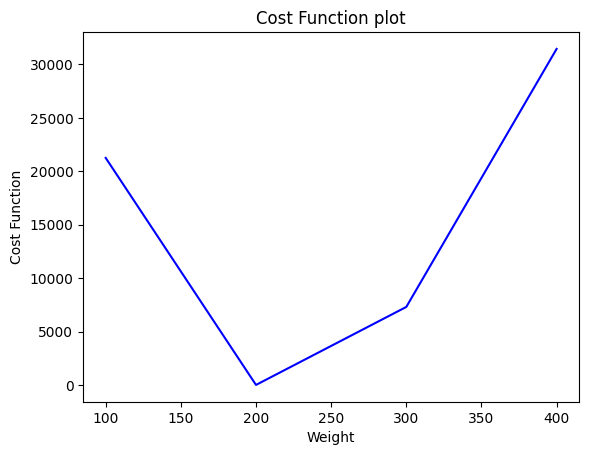

In [ ]:
plt.plot(w,cost,c='b')

plt.title("Cost Function plot")
plt.xlabel("Weight")
plt.ylabel("Cost Function")

plt.show()

In [ ]:
# Implementing Gradient Descent - Single Feature Linear Regression

def compute_derivate(x,y,w,b):
  """
    Computing the derivatives for gradient Descent
    Input Arguments : x(ndarray) , y(ndarray) - target values , w(weight) and b(bias)
    Output values : dj_dw = The gradient of the Cost with respect to weight
                    dj_db = The gradient of the Cost with respect to bias

  """
  m = x.shape[0]
  dj_dw = 0
  dj_db = 0
  for i in range(m):
    f_wb = w*x[i] + b
    dj_dwi = (f_wb - y[i])*x[i]
    dj_dbi = (f_wb - y[i])
    dj_dw += dj_dwi
    dj_db += dj_dbi

  dj_dw = dj_dw/m
  dj_db = dj_dw/m

  return dj_dw,dj_db


In [ ]:
# Implementing the Gradient Descent function
import math

def gradient_descent(x,y,w_in,b_in,alpha,compute_cost,compute_derivate,num_iters):

  """
   Performs gradient descent to fit w,b. Updates w,b by taking
    num_iters gradient steps with learning rate alpha

    Arguments:
      x (ndarray) : Data, m examples
      y (ndarray)  : target values
      w_in,b_in (scalar): initial values of model parameters
      alpha :     Learning rate
      num_iters :   number of iterations to run gradient descent
      compute_cost:     function to call to produce cost
      compute_derivate : function to call to produce gradient

    Returns:
      w (scalar): Updated value of parameter after running gradient descent
      b (scalar): Updated value of parameter after running gradient descent
      J_history (List): History of cost values
      model_history (list): History of parameters [w,b]
  """
  w = w_in
  b=  b_in
  J_history = []
  model_history = []

  for i in range(num_iters):
    dj_dw , dj_db = compute_derivate(x,y,w,b)

    w = w - alpha*dj_dw
    b = b - alpha*dj_db

    if i<100000:
      J_history.append(compute_cost(x,y,w,b))
      model_history.append([w,b])

    if i% math.ceil(num_iters/10) == 0:
            print(f"Iteration {i:4}: Cost {J_history[-1]:0.2e} ",
                  f"dj_dw: {dj_dw: 0.3e}, dj_db: {dj_db: 0.3e}  ",
                  f"w: {w: 0.3e}, b:{b: 0.5e}")

  return w,b,J_history,model_history


In [ ]:
# Input

w_in = 0
b_in = 0

iteration = 10000
alpha_val = 1.0e-2

#Output
w_final,b_final , J_hist, model_hist = gradient_descent(x_train,y_train,w_in,b_in,alpha_val,compute_cost,compute_derivate,iteration)

print(f"(w,b) values after total iterations : ({w_final :8.4f} , {b_final :8.4f})")

Iteration    0: Cost 7.96e+04  dj_dw: -6.500e+02, dj_db: -3.250e+02   w:  6.500e+00, b: 3.25000e+00
Iteration 1000: Cost 1.76e-24  dj_dw: -3.041e-12, dj_db: -1.521e-12   w:  2.000e+02, b: 1.00000e+02
Iteration 2000: Cost 3.89e-25  dj_dw: -1.393e-12, dj_db: -6.963e-13   w:  2.000e+02, b: 1.00000e+02
Iteration 3000: Cost 3.89e-25  dj_dw: -1.393e-12, dj_db: -6.963e-13   w:  2.000e+02, b: 1.00000e+02
Iteration 4000: Cost 3.89e-25  dj_dw: -1.393e-12, dj_db: -6.963e-13   w:  2.000e+02, b: 1.00000e+02
Iteration 5000: Cost 3.89e-25  dj_dw: -1.393e-12, dj_db: -6.963e-13   w:  2.000e+02, b: 1.00000e+02
Iteration 6000: Cost 3.89e-25  dj_dw: -1.393e-12, dj_db: -6.963e-13   w:  2.000e+02, b: 1.00000e+02
Iteration 7000: Cost 3.89e-25  dj_dw: -1.393e-12, dj_db: -6.963e-13   w:  2.000e+02, b: 1.00000e+02
Iteration 8000: Cost 3.89e-25  dj_dw: -1.393e-12, dj_db: -6.963e-13   w:  2.000e+02, b: 1.00000e+02
Iteration 9000: Cost 3.89e-25  dj_dw: -1.393e-12, dj_db: -6.963e-13   w:  2.000e+02, b: 1.00000e+02


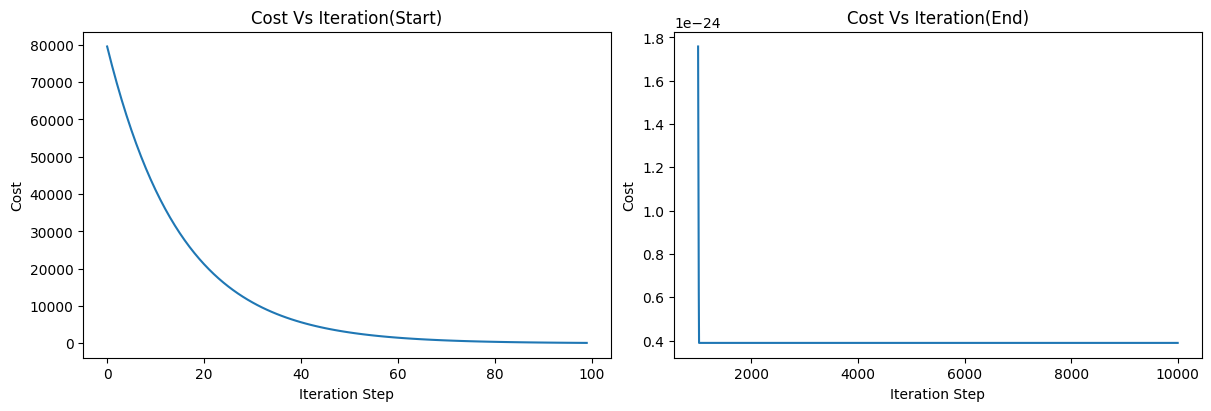

In [ ]:
# Plotting Cost Function against No of Iteration

fig,(ax1,ax2) = plt.subplots(1,2,constrained_layout = True , figsize =(12,4))

ax1.plot(J_hist[:100])
ax2.plot(1000 + np.arange(len(J_hist[1000:])),J_hist[1000:])
ax1.set_title("Cost Vs Iteration(Start)")
ax2.set_title("Cost Vs Iteration(End)")

ax1.set_xlabel("Iteration Step")
ax2.set_xlabel("Iteration Step")

ax1.set_ylabel("Cost")
ax2.set_ylabel("Cost")

plt.show()